# Unified Anomaly Detection in Regional Energy Consumption (4 Methods)

This notebook builds a unified anomaly detection pipeline for regional electricity demand across four complementary methods:

- **Z-Score** — global spike detector
- **IQR** — local distribution outlier detector
- **Isolation Forest** — context-aware multivariate detector
- **LSTM Autoencoder** — sequence reconstruction detector for temporal pattern anomalies

The workflow is fully reproducible, scalable across regions, and calibrated with a shared target anomaly rate for fair cross-method comparison.

It produces Tableau-ready outputs including:
- row-level anomaly flags and consensus labels,
- method-level overlap and vote counts,
- region-wise and global method summary tables.

## Step 1 — Setup, Paths, and Shared Utilities

In [75]:
from pathlib import Path
import copy
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from IPython.display import display
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

# Shared calibration targets across methods (single place to tune sensitivity)
GLOBAL_TARGET_ANOMALY_RATE = 0.02
CALIBRATION_RATE_MIN = 0.01
CALIBRATION_RATE_MAX = 0.05


def find_project_root(start: Path) -> Path:
    """Walk up directories until pyproject.toml is found."""
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    return start


def normalize_name(name: str) -> str:
    """Normalize a column name for robust matching."""
    return re.sub(r"[^a-z0-9]+", "", str(name).strip().lower())


def save_and_show_plot(fig, filename: str, output_dir: Path) -> None:
    """Save plot for dashboard usage and render it inline."""
    output_dir.mkdir(parents=True, exist_ok=True)
    file_path = output_dir / filename
    fig.savefig(file_path, dpi=300, bbox_inches="tight")
    print(f"Saved plot: {file_path}")
    plt.show()


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_PATH = PROJECT_ROOT / "output" / "engineered_features.csv"
OUTPUT_DIR = PROJECT_ROOT / "output"

print(f"Project root: {PROJECT_ROOT}")
print(f"Data path:     {DATA_PATH}")
print(f"Output dir:    {OUTPUT_DIR}")
print(f"Global target anomaly rate: {GLOBAL_TARGET_ANOMALY_RATE*100:.2f}%")

Project root: /home/bhavik/Dropbox/edu/smu/winter/data_mining/a6_anomaly_detection
Data path:     /home/bhavik/Dropbox/edu/smu/winter/data_mining/a6_anomaly_detection/output/engineered_features.csv
Output dir:    /home/bhavik/Dropbox/edu/smu/winter/data_mining/a6_anomaly_detection/output
Global target anomaly rate: 2.00%


**Analysis:**

This setup cell centralizes dependencies and directory handling. Using `Pathlib` and `find_project_root()` makes the notebook portable regardless of where it is launched from. The `save_and_show_plot()` helper standardizes chart exports for Tableau and report artifacts.

**Calibration note:** Tune `GLOBAL_TARGET_ANOMALY_RATE` once in Step 1 to control alert volume consistently across Isolation Forest and Autoencoder fallback calibration.

## Step 2 — Data Loading & Feature Alignment

In [76]:
raw_df = pd.read_csv(DATA_PATH)
print(f"Loaded shape: {raw_df.shape}")

expected_columns = [
    "timestamp",
    "region",
    "consumption_kwh",
    "consumption_kwh_lag_1h",
    "consumption_kwh_lag_24h",
    "rolling_mean_168h",
    "rolling_std_24h",
    "temperature_c",
    "humidity_pct",
    "hour",
    "day_of_week",
]

missing_columns = [col for col in expected_columns if col not in raw_df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns in engineered_features.csv: {missing_columns}")

df = raw_df[expected_columns].copy()

df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df = (
    df.dropna(subset=["timestamp", "region"])
    .sort_values(["region", "timestamp"])
    .reset_index(drop=True)
)

feature_columns = [
    "consumption_kwh_lag_1h",
    "consumption_kwh_lag_24h",
    "rolling_mean_168h",
    "rolling_std_24h",
    "temperature_c",
    "humidity_pct",
    "hour",
    "day_of_week",
]

fill_columns = ["consumption_kwh", *feature_columns]
for column in fill_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

    # Fill within each region using interpolation first, then regional mean
    df[column] = (
        df.groupby("region", group_keys=False)[column]
        .apply(lambda series: series.interpolate(limit_direction="both"))
        .astype(float)
    )

    regional_mean = df.groupby("region")[column].transform("mean")
    df[column] = df[column].fillna(regional_mean)
    df[column] = df[column].fillna(df[column].mean())

print("Prepared columns:")
print(df.columns.tolist())
print(f"Rows after cleaning: {len(df):,}")
display(df.head())

Loaded shape: (438240, 32)
Prepared columns:
['timestamp', 'region', 'consumption_kwh', 'consumption_kwh_lag_1h', 'consumption_kwh_lag_24h', 'rolling_mean_168h', 'rolling_std_24h', 'temperature_c', 'humidity_pct', 'hour', 'day_of_week']
Rows after cleaning: 438,240


,timestamp,region,consumption_kwh,consumption_kwh_lag_1h,consumption_kwh_lag_24h,rolling_mean_168h,rolling_std_24h,temperature_c,humidity_pct,hour,day_of_week
0,2015-01-02 00:00:00,Annapolis Valley,114.19,125.58,125.53,205.136000,144.622016,-8.8,60.1,0.0,4.0
1,2015-01-02 01:00:00,Annapolis Valley,113.90,114.19,94.93,201.626923,144.025200,8.5,50.0,1.0,4.0
2,2015-01-02 02:00:00,Annapolis Valley,96.57,113.90,103.48,197.735926,144.252549,2.2,88.3,2.0,4.0
3,2015-01-02 03:00:00,Annapolis Valley,112.05,96.57,82.12,194.675714,143.234144,-1.8,67.5,3.0,4.0
4,2015-01-02 04:00:00,Annapolis Valley,124.48,112.05,81.56,192.255172,141.819107,-6.2,57.2,4.0,4.0


**Analysis:**

This section ensures the exact forecasting feature family is available: lags (1h, 24h), rolling statistics (168h mean, 24h std), weather (temperature, humidity), and calendar context (hour, day-of-week). Missing values are handled region-wise first (interpolation + regional mean) and globally as fallback to preserve scale for robust modeling.

## Step 3 — Univariate Baseline Detection (Z-Score and IQR)

In [77]:
df["zscore_anomaly"] = False
df["iqr_anomaly"] = False

for region_name in df["region"].dropna().unique():
    region_mask = df["region"] == region_name
    series = df.loc[region_mask, "consumption_kwh"].astype(float)

    # Z-Score anomaly (global spike detector)
    mean_value = series.mean()
    std_value = series.std(ddof=0)
    if std_value > 0:
        z_scores = (series - mean_value) / std_value
        df.loc[region_mask, "zscore_anomaly"] = z_scores.abs() > 3

    # IQR anomaly (local distribution detector)
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    df.loc[region_mask, "iqr_anomaly"] = (series < lower_bound) | (series > upper_bound)

baseline_rates = pd.DataFrame(
    {
        "Method": ["Z-Score", "IQR"],
        "Detection Rate (%)": [
            df["zscore_anomaly"].mean() * 100,
            df["iqr_anomaly"].mean() * 100,
        ],
    }
)

display(baseline_rates.style.format({"Detection Rate (%)": "{:.2f}"}))

,Method,Detection Rate (%)
0,Z-Score,0.77
1,IQR,1.51


**Analysis:**

Z-Score is a **global** detector: it highlights observations far from a region’s overall mean (large, loud spikes). IQR is a **local distribution** detector: it identifies points outside robust quartile bounds and is less sensitive to a few extreme values. Together they provide a strong statistical baseline before machine-learning detection.

## Step 4 — Multivariate Detection with Isolation Forest

In [78]:
# Calibrate Isolation Forest to a target anomaly rate to keep method outputs comparable.
iso_target_rate = GLOBAL_TARGET_ANOMALY_RATE

df["isolation_forest_anomaly"] = False

for idx, region_name in enumerate(df["region"].dropna().unique(), start=1):
    print(f"Processing region {idx}: {region_name} ...")
    region_mask = df["region"] == region_name
    region_features = df.loc[region_mask, feature_columns].astype(float)

    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(region_features)

    iso_model = IsolationForest(
        contamination=iso_target_rate,
        random_state=42,
        n_estimators=200,
        n_jobs=-1,
    )
    iso_predictions = iso_model.fit_predict(scaled_features)
    df.loc[region_mask, "isolation_forest_anomaly"] = iso_predictions == -1

iso_rate = df["isolation_forest_anomaly"].mean() * 100
print(f"Isolation Forest detection rate: {iso_rate:.2f}% (target={iso_target_rate*100:.2f}%)")

Processing region 1: Annapolis Valley ...
Processing region 2: Cape Breton ...
Processing region 3: Halifax ...
Processing region 4: Pictou County ...
Processing region 5: South Shore ...
Isolation Forest detection rate: 2.00% (target=2.00%)


**Analysis:**

Isolation Forest was previously high because `contamination='auto'` uses an internal score threshold that can mark a larger fraction of points as outliers on heterogeneous regional data. To keep all methods in a comparable operating range, we calibrate `contamination` to a target rate (2%). This does not make methods identical, but it aligns alert volume so cross-method comparison is fairer.

## Step 5 — Tier 1 + Tier 2 Interim Checkpoint

In [79]:
tier12_method_columns = ["zscore_anomaly", "iqr_anomaly", "isolation_forest_anomaly"]
df["tier12_votes"] = df[tier12_method_columns].sum(axis=1)

tier12_preview = (
    pd.DataFrame(
        {
            "Method": ["Z-Score", "IQR", "Isolation Forest"],
            "Detection Rate (%)": [
                df["zscore_anomaly"].mean() * 100,
                df["iqr_anomaly"].mean() * 100,
                df["isolation_forest_anomaly"].mean() * 100,
            ],
        }
    )
    .sort_values("Detection Rate (%)", ascending=False)
    .reset_index(drop=True)
)

display(tier12_preview.style.format({"Detection Rate (%)": "{:.2f}"}))

,Method,Detection Rate (%)
0,Isolation Forest,2.00
1,IQR,1.51
2,Z-Score,0.77


**Analysis:**

This checkpoint summarizes statistical and classical ML detectors only. The final consensus is computed later after adding the deep-learning detector.

## Step 5.1 — Interim Tier 1+2 Visualization

In [80]:
# Keep this as a quick checkpoint only (no standalone plot export).
tier12_comparison_df = pd.DataFrame(
    {
        "Method": ["Z-Score", "IQR", "Isolation Forest"],
        "Detection Rate (%)": [
            df["zscore_anomaly"].mean() * 100,
            df["iqr_anomaly"].mean() * 100,
            df["isolation_forest_anomaly"].mean() * 100,
        ],
    }
)

display(tier12_comparison_df.style.format({"Detection Rate (%)": "{:.2f}"}))

,Method,Detection Rate (%)
0,Z-Score,0.77
1,IQR,1.51
2,Isolation Forest,2.00


**Analysis:**

This plot is a pre-autoencoder baseline. The final four-method comparison and consensus chart are generated at the bottom after the deep-learning tier is scored.

## Step 5.2 — Optional Tier 1+2 Export

In [81]:
# Removed separate Tier 1/2 export.
# Final unified export (all 4 methods) is generated in Step 10.
print("Tier 1/2 standalone export skipped. Use final 4-method export in Step 10.")

Tier 1/2 standalone export skipped. Use final 4-method export in Step 10.


## Flow Note

The notebook now follows a tiered progression:

1. Tier 1: Statistical methods (Z-Score, IQR)
2. Tier 2: Machine learning (Isolation Forest)
3. Tier 3: Deep learning (LSTM Autoencoder)
4. Final section: Four-method overlap, consensus, and export

## Step 8 — Deep Learning Tier: LSTM Autoencoder (PyTorch)

This section adds a reconstruction-based anomaly detector. The model learns to reconstruct normal 24-hour behavior, and high reconstruction error indicates unusual sequence structure.

In [82]:
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


**Analysis:**

For the autoencoder, each sample is a 24-hour multivariate window. Features are standardized so the model can learn joint temporal structure instead of being dominated by raw feature scale.

## Step 6 — Deep Learning Data Prep: `create_sequences` + MinMaxScaler

In [83]:
window_size = 24
ae_feature_columns = [
    "consumption_kwh",
    "temperature_c",
    "humidity_pct",
    "consumption_kwh_lag_1h",
    "consumption_kwh_lag_24h",
]


def create_sequences(data: np.ndarray, window_size: int = 24) -> np.ndarray:
    """Convert 2D array (rows, features) to 3D array (samples, time_steps, features)."""
    if len(data) < window_size:
        return np.empty((0, window_size, data.shape[1]))
    return np.stack([data[i : i + window_size] for i in range(len(data) - window_size + 1)], axis=0)


region_sequence_store = {}
sequence_blocks = []
sequence_end_index_blocks = []

for region_name in df["region"].dropna().unique():
    region_slice = df[df["region"] == region_name].copy().sort_values("timestamp")

    scaler = MinMaxScaler()
    scaled_values = scaler.fit_transform(region_slice[ae_feature_columns].values)
    region_sequences = create_sequences(scaled_values, window_size=window_size)

    if len(region_sequences) == 0:
        continue

    end_positions = region_slice.index.values[window_size - 1 :]

    region_sequence_store[region_name] = {
        "sequences": region_sequences,
        "end_positions": end_positions,
        "scaler": scaler,
    }
    sequence_blocks.append(region_sequences)
    sequence_end_index_blocks.append(end_positions)

X_all = np.concatenate(sequence_blocks, axis=0)
sequence_end_index = np.concatenate(sequence_end_index_blocks, axis=0)

print(f"Region count for AE: {len(region_sequence_store)}")
print(f"Sequence tensor shape: {X_all.shape}")
print(f"Mapped row count: {len(sequence_end_index):,}")

Region count for AE: 5
Sequence tensor shape: (438125, 24, 5)
Mapped row count: 438,125


## Step 7 — Model: `LSTMAutoencoder`

In [84]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, n_features: int, hidden_size: int = 16, latent_size: int = 8, num_layers: int = 1):
        super().__init__()
        self.encoder = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        self.to_latent = nn.Linear(hidden_size, latent_size)
        self.from_latent = nn.Linear(latent_size, hidden_size)
        self.decoder = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        self.output_layer = nn.Linear(hidden_size, n_features)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        encoded_seq, _ = self.encoder(x)
        context = encoded_seq[:, -1, :]
        latent = self.to_latent(context)
        decoder_seed = self.from_latent(latent)
        repeated_seed = decoder_seed.unsqueeze(1).repeat(1, x.size(1), 1)
        decoded_seq, _ = self.decoder(repeated_seed)
        reconstruction = self.output_layer(decoded_seq)
        return reconstruction


n_features = len(ae_feature_columns)
print(f"AE input features: {n_features}")

AE input features: 5


## Step 8 — Training: 30-Epoch Loop per Region

The objective is reconstruction: each regional model learns to memorize normal sequence dynamics. High reconstruction error indicates structural behavior that deviates from learned normal patterns.

Training AE for region: Annapolis Valley
  Epoch 01/30 - train_loss: 0.019942
  Epoch 02/30 - train_loss: 0.009914
  Epoch 03/30 - train_loss: 0.009879
  Epoch 04/30 - train_loss: 0.009870
  Epoch 05/30 - train_loss: 0.009814
  Epoch 06/30 - train_loss: 0.009592
  Epoch 07/30 - train_loss: 0.009522
  Epoch 08/30 - train_loss: 0.009487
  Epoch 09/30 - train_loss: 0.009475
  Epoch 10/30 - train_loss: 0.009470
  Epoch 11/30 - train_loss: 0.009467
  Epoch 12/30 - train_loss: 0.009462
  Epoch 13/30 - train_loss: 0.009438
  Epoch 14/30 - train_loss: 0.009423
  Epoch 15/30 - train_loss: 0.009418
  Epoch 16/30 - train_loss: 0.009411
  Epoch 17/30 - train_loss: 0.009325
  Epoch 18/30 - train_loss: 0.009254
  Epoch 19/30 - train_loss: 0.009226
  Epoch 20/30 - train_loss: 0.009098
  Epoch 21/30 - train_loss: 0.008972
  Epoch 22/30 - train_loss: 0.008928
  Epoch 23/30 - train_loss: 0.008889
  Epoch 24/30 - train_loss: 0.008857
  Epoch 25/30 - train_loss: 0.008833
  Epoch 26/30 - train_loss: 0.0088

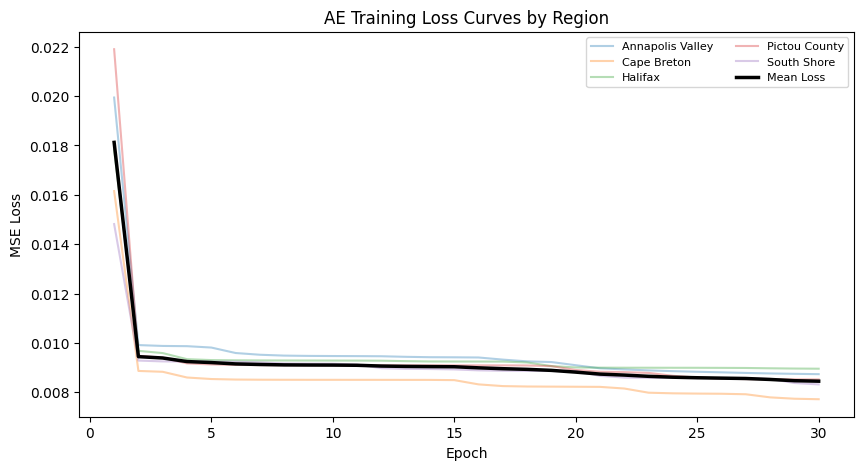

In [85]:
epochs = 30
batch_size = 128
learning_rate = 1e-3
early_stopping_patience = 5

models_by_region = {}
region_histories = {}

for region_name, payload in region_sequence_store.items():
    print(f"Training AE for region: {region_name}")
    region_sequences = payload["sequences"]

    model = LSTMAutoencoder(n_features=n_features, hidden_size=16, latent_size=8).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    train_tensor = torch.tensor(region_sequences, dtype=torch.float32)
    train_loader = DataLoader(TensorDataset(train_tensor), batch_size=batch_size, shuffle=True)

    # Use a concrete, sized object for length (train_tensor) to avoid typing/runtime issues
    dataset_len = len(train_tensor)

    best_state = None
    best_loss = float("inf")
    no_improve_epochs = 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0

        for (batch_x,) in train_loader:
            batch_x = batch_x.to(DEVICE)
            optimizer.zero_grad()
            recon_x = model(batch_x)
            loss = criterion(recon_x, batch_x)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * batch_x.size(0)

        epoch_loss = running_loss / float(dataset_len)
        history.append(epoch_loss)
        print(f"  Epoch {epoch:02d}/{epochs} - train_loss: {epoch_loss:.6f}")

        if epoch_loss < best_loss - 1e-6:
            best_loss = epoch_loss
            best_state = copy.deepcopy(model.state_dict())
            no_improve_epochs = 0
        else:
            no_improve_epochs += 1

        if no_improve_epochs >= early_stopping_patience:
            print(f"  Early stopping triggered at epoch {epoch}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    models_by_region[region_name] = model
    region_histories[region_name] = history

# Plot per-region training curves
fig, ax = plt.subplots(figsize=(10, 5))
for region_name, history in region_histories.items():
    ax.plot(range(1, len(history) + 1), history, alpha=0.35, linewidth=1.5, label=region_name)

# Mean loss curve across regions (with NaN padding)
max_len = max(len(history) for history in region_histories.values())
loss_matrix = np.full((len(region_histories), max_len), np.nan)
for row_idx, history in enumerate(region_histories.values()):
    loss_matrix[row_idx, : len(history)] = history
mean_curve = np.nanmean(loss_matrix, axis=0)
ax.plot(range(1, max_len + 1), mean_curve, color="black", linewidth=2.5, label="Mean Loss")

ax.set_title("AE Training Loss Curves by Region")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.legend(loc="upper right", ncol=2, fontsize=8)
save_and_show_plot(fig, "ae_training_loss_curve.png", OUTPUT_DIR)

## Step 9 — Scoring: Robust-MAD Thresholding + Calibrated Fallback

Annapolis Valley: method=MAD, threshold=0.013774, flag_rate=3.60%
Cape Breton: method=MAD, threshold=0.012181, flag_rate=3.08%
Halifax: method=MAD, threshold=0.013958, flag_rate=3.40%
Pictou County: method=MAD, threshold=0.013369, flag_rate=3.35%
South Shore: method=MAD, threshold=0.013065, flag_rate=3.59%
AE anomalous windows: 14,912
AE overall detection rate: 3.40%
Saved plot: /home/bhavik/Dropbox/edu/smu/winter/data_mining/a6_anomaly_detection/output/ae_original_vs_reconstructed.png


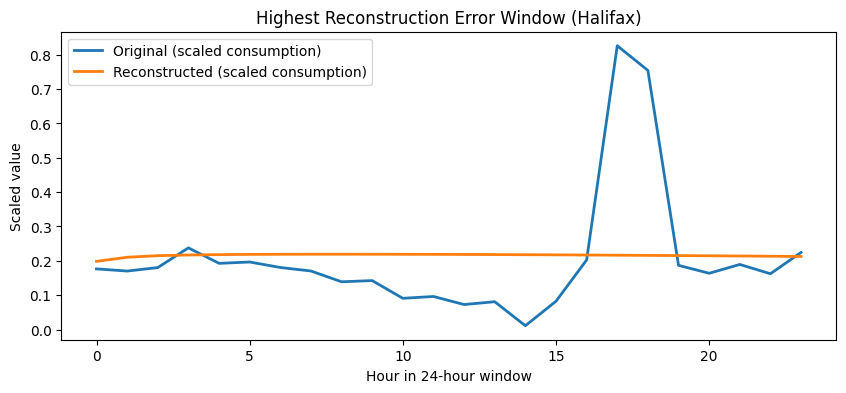

In [86]:
# Robust thresholding setup for AE reconstruction errors.
# Primary rule: median + k * MAD
# Fallback: use quantile threshold if resulting rate is outside calibration band.
ae_target_rate = GLOBAL_TARGET_ANOMALY_RATE
mad_k = 3.5
rate_min, rate_max = CALIBRATION_RATE_MIN, CALIBRATION_RATE_MAX

df["ae_reconstruction_error"] = np.nan
df["ae_anomaly"] = False

ae_window_records = []
highest_error_payload = None

for region_name, payload in region_sequence_store.items():
    model = models_by_region[region_name]
    region_sequences = payload["sequences"]
    end_positions = payload["end_positions"]

    model.eval()
    seq_tensor = torch.tensor(region_sequences, dtype=torch.float32)
    seq_loader = DataLoader(TensorDataset(seq_tensor), batch_size=512, shuffle=False)

    region_errors = []
    region_recon = []

    with torch.no_grad():
        for (batch_x,) in seq_loader:
            batch_x = batch_x.to(DEVICE)
            recon_x = model(batch_x)
            mse = ((recon_x - batch_x) ** 2).mean(dim=(1, 2)).detach().cpu().numpy()
            region_errors.append(mse)
            region_recon.append(recon_x.detach().cpu().numpy())

    region_errors = np.concatenate(region_errors, axis=0)
    region_recon = np.concatenate(region_recon, axis=0)

    median_err = float(np.median(region_errors))
    mad_err = float(np.median(np.abs(region_errors - median_err)))

    if mad_err > 0:
        mad_threshold = median_err + mad_k * mad_err
        region_flags = region_errors >= mad_threshold
        threshold_used = mad_threshold
        threshold_method = "MAD"
    else:
        q_threshold = float(np.quantile(region_errors, 1 - ae_target_rate))
        region_flags = region_errors >= q_threshold
        threshold_used = q_threshold
        threshold_method = "QuantileFallback"

    flagged_rate = float(region_flags.mean())
    if (flagged_rate < rate_min) or (flagged_rate > rate_max):
        q_threshold = float(np.quantile(region_errors, 1 - ae_target_rate))
        region_flags = region_errors >= q_threshold
        threshold_used = q_threshold
        threshold_method = "QuantileCalibrated"
        flagged_rate = float(region_flags.mean())

    print(
        f"{region_name}: method={threshold_method}, threshold={threshold_used:.6f}, "
        f"flag_rate={flagged_rate*100:.2f}%"
    )

    df.loc[end_positions, "ae_reconstruction_error"] = region_errors
    df.loc[end_positions, "ae_anomaly"] = region_flags

    region_table = pd.DataFrame(
        {
            "region": region_name,
            "row_index": end_positions,
            "ae_reconstruction_error": region_errors,
            "ae_anomaly": region_flags,
            "threshold_method": threshold_method,
            "threshold_value": threshold_used,
            "flag_rate": flagged_rate,
        }
    )
    ae_window_records.append(region_table)

    local_max_idx = int(np.argmax(region_errors))
    local_max_error = float(region_errors[local_max_idx])
    if highest_error_payload is None or local_max_error > highest_error_payload["error"]:
        highest_error_payload = {
            "error": local_max_error,
            "region": region_name,
            "original": region_sequences[local_max_idx],
            "reconstructed": region_recon[local_max_idx],
        }

ae_window_results = pd.concat(ae_window_records, ignore_index=True)
print(f"AE anomalous windows: {int(ae_window_results['ae_anomaly'].sum()):,}")
print(f"AE overall detection rate: {df['ae_anomaly'].mean()*100:.2f}%")

# Diagnostic reconstruction plot for highest-error window
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(highest_error_payload["original"][:, 0], label="Original (scaled consumption)", linewidth=2)
ax.plot(highest_error_payload["reconstructed"][:, 0], label="Reconstructed (scaled consumption)", linewidth=2)
ax.set_title(
    f"Highest Reconstruction Error Window ({highest_error_payload['region']})"
)
ax.set_xlabel("Hour in 24-hour window")
ax.set_ylabel("Scaled value")
ax.legend()
save_and_show_plot(fig, "ae_original_vs_reconstructed.png", OUTPUT_DIR)

## Step 10 — The Grand Results: 4-Method Consensus and Export

This final step aligns all flags by timestamp and region, computes overlap statistics, visualizes all four detection rates, and exports the final comparison dataset.

--- Method Overlap Analysis (1 to 4 methods) ---


,methods_flagged,count,share_%
0,1,16158,3.69
1,2,6846,1.56
2,3,752,0.17
3,4,385,0.09


Saved plot: /home/bhavik/Dropbox/edu/smu/winter/data_mining/a6_anomaly_detection/output/anomaly_detection_rate_4method_comparison.png


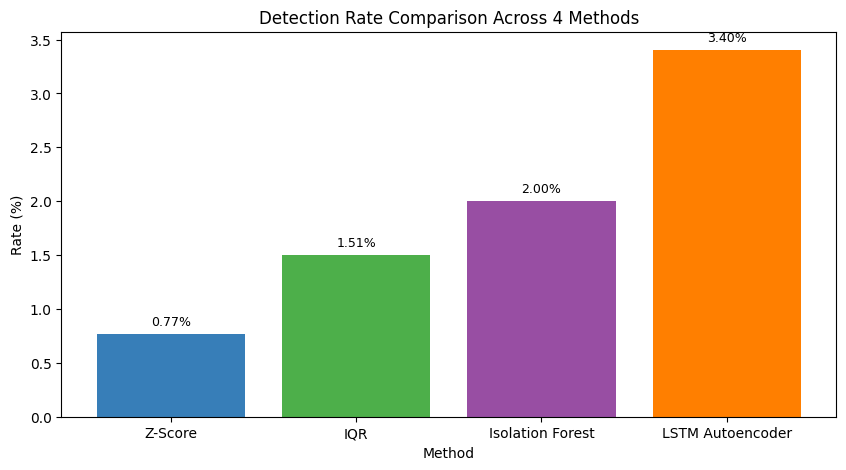

--- Region-wise × Method-wise Anomaly Summary ---


,region,method,total_anomaly,region_total_rows,pct_of_region_%,pct_of_global_%
0,Annapolis Valley,IQR,1093,87648,1.25,0.25
1,Annapolis Valley,Isolation Forest,1753,87648,2.00,0.40
2,Annapolis Valley,LSTM Autoencoder,3151,87648,3.60,0.72
3,Annapolis Valley,Z-Score,720,87648,0.82,0.16
4,Cape Breton,IQR,1644,87648,1.88,0.38
5,Cape Breton,Isolation Forest,1753,87648,2.00,0.40
6,Cape Breton,LSTM Autoencoder,2698,87648,3.08,0.62
7,Cape Breton,Z-Score,692,87648,0.79,0.16
8,Halifax,IQR,1304,87648,1.49,0.30
9,Halifax,Isolation Forest,1753,87648,2.00,0.40


--- Global Method Summary ---


,method,total_anomaly,pct_of_total_rows_%,pct_within_all_flagged_methods_%
2,LSTM Autoencoder,14912,3.40,44.32
1,Isolation Forest,8765,2.00,26.05
0,IQR,6596,1.51,19.60
3,Z-Score,3373,0.77,10.02


Export completed: /home/bhavik/Dropbox/edu/smu/winter/data_mining/a6_anomaly_detection/output/autoencoder_results.csv
Export completed: /home/bhavik/Dropbox/edu/smu/winter/data_mining/a6_anomaly_detection/output/anomaly_results.csv
Export completed: /home/bhavik/Dropbox/edu/smu/winter/data_mining/a6_anomaly_detection/output/region_method_summary.csv
Export completed: /home/bhavik/Dropbox/edu/smu/winter/data_mining/a6_anomaly_detection/output/global_method_summary.csv
Rows exported: 438,240
High-confidence consensus rows: 7,983


In [87]:
unified_anomaly_df = df[
    [
        "timestamp",
        "region",
        "consumption_kwh",
        "zscore_anomaly",
        "iqr_anomaly",
        "isolation_forest_anomaly",
        "ae_anomaly",
        "ae_reconstruction_error",
    ]
].copy()

flag_columns = [
    "zscore_anomaly",
    "iqr_anomaly",
    "isolation_forest_anomaly",
    "ae_anomaly",
]
method_name_map = {
    "zscore_anomaly": "Z-Score",
    "iqr_anomaly": "IQR",
    "isolation_forest_anomaly": "Isolation Forest",
    "ae_anomaly": "LSTM Autoencoder",
}

for col in flag_columns:
    unified_anomaly_df[col] = unified_anomaly_df[col].fillna(False).astype(bool)

unified_anomaly_df["method_votes"] = unified_anomaly_df[flag_columns].sum(axis=1)
unified_anomaly_df["high_confidence_consensus"] = unified_anomaly_df["method_votes"] >= 2
unified_anomaly_df["anomaly_flag"] = unified_anomaly_df["high_confidence_consensus"]


def list_triggered_methods(row: pd.Series) -> str:
    return ", ".join([method_name_map[col] for col in flag_columns if bool(row[col])])


unified_anomaly_df["anomaly_method"] = unified_anomaly_df.apply(list_triggered_methods, axis=1)
unified_anomaly_df["anomaly_type"] = np.select(
    [
        unified_anomaly_df["method_votes"] >= 2,
        unified_anomaly_df["method_votes"] == 1,
    ],
    ["High Confidence", "Single Method"],
    default="Normal",
)

# Method overlap analysis: flagged by 1, 2, 3, or 4 methods
overlap_analysis = pd.DataFrame(
    {
        "methods_flagged": [1, 2, 3, 4],
        "count": [
            int((unified_anomaly_df["method_votes"] == n).sum())
            for n in [1, 2, 3, 4]
        ],
    }
)
overlap_analysis["share_%"] = overlap_analysis["count"] / len(unified_anomaly_df) * 100

print("--- Method Overlap Analysis (1 to 4 methods) ---")
display(overlap_analysis.style.format({"share_%": "{:.2f}"}))

# Final 4-method detection-rate chart
final_rate_df = pd.DataFrame(
    {
        "Method": ["Z-Score", "IQR", "Isolation Forest", "LSTM Autoencoder"],
        "Detection Rate (%)": [
            unified_anomaly_df["zscore_anomaly"].mean() * 100,
            unified_anomaly_df["iqr_anomaly"].mean() * 100,
            unified_anomaly_df["isolation_forest_anomaly"].mean() * 100,
            unified_anomaly_df["ae_anomaly"].mean() * 100,
        ],
    }
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(
    final_rate_df["Method"],
    final_rate_df["Detection Rate (%)"],
    color=["#377eb8", "#4daf4a", "#984ea3", "#ff7f00"],
)
ax.set_title("Detection Rate Comparison Across 4 Methods")
ax.set_xlabel("Method")
ax.set_ylabel("Rate (%)")
for idx, val in enumerate(final_rate_df["Detection Rate (%)"]):
    ax.text(idx, val + 0.05, f"{val:.2f}%", ha="center", va="bottom", fontsize=9)

save_and_show_plot(fig, "anomaly_detection_rate_4method_comparison.png", OUTPUT_DIR)

# Region-wise and method-wise anomaly summary for dashboarding
long_flags_df = (
    unified_anomaly_df[["region", *flag_columns]]
    .melt(id_vars="region", var_name="method_col", value_name="is_anomaly")
)
long_flags_df["method"] = long_flags_df["method_col"].map(method_name_map)
long_flags_df["is_anomaly"] = long_flags_df["is_anomaly"].astype(int)

region_totals = unified_anomaly_df.groupby("region", as_index=False).size().rename(columns={"size": "region_total_rows"})

region_method_summary = (
    long_flags_df.groupby(["region", "method"], as_index=False)
    .agg(total_anomaly=("is_anomaly", "sum"))
    .merge(region_totals, on="region", how="left")
)
region_method_summary["pct_of_region_%"] = (
    region_method_summary["total_anomaly"] / region_method_summary["region_total_rows"] * 100
)
region_method_summary["pct_of_global_%"] = (
    region_method_summary["total_anomaly"] / len(unified_anomaly_df) * 100
)

print("--- Region-wise × Method-wise Anomaly Summary ---")
display(
    region_method_summary.sort_values(["region", "method"]).style.format(
        {
            "pct_of_region_%": "{:.2f}",
            "pct_of_global_%": "{:.2f}",
        }
    )
)

global_method_summary = (
    long_flags_df.groupby("method", as_index=False)
    .agg(total_anomaly=("is_anomaly", "sum"))
)
global_method_summary["pct_of_total_rows_%"] = (
    global_method_summary["total_anomaly"] / len(unified_anomaly_df) * 100
)

total_method_flags = global_method_summary["total_anomaly"].sum()
global_method_summary["pct_within_all_flagged_methods_%"] = np.where(
    total_method_flags > 0,
    global_method_summary["total_anomaly"] / total_method_flags * 100,
    0.0,
)

print("--- Global Method Summary ---")
display(
    global_method_summary.sort_values("total_anomaly", ascending=False).style.format(
        {
            "pct_of_total_rows_%": "{:.2f}",
            "pct_within_all_flagged_methods_%": "{:.2f}",
        }
    )
)

# Final export with Tableau-friendly fields
final_export_columns = [
    "timestamp",
    "region",
    "consumption_kwh",
    "anomaly_flag",
    "anomaly_type",
    "zscore_anomaly",
    "iqr_anomaly",
    "isolation_forest_anomaly",
    "ae_anomaly",
    "high_confidence_consensus",
    "method_votes",
    "anomaly_method",
    "ae_reconstruction_error",
]

autoencoder_results = unified_anomaly_df[final_export_columns].copy()
ae_export_path = OUTPUT_DIR / "autoencoder_results.csv"
final_anomaly_export_path = OUTPUT_DIR / "anomaly_results.csv"
region_method_summary_path = OUTPUT_DIR / "region_method_summary.csv"
global_method_summary_path = OUTPUT_DIR / "global_method_summary.csv"

autoencoder_results.to_csv(ae_export_path, index=False)
autoencoder_results.to_csv(final_anomaly_export_path, index=False)
region_method_summary.to_csv(region_method_summary_path, index=False)
global_method_summary.to_csv(global_method_summary_path, index=False)

print(f"Export completed: {ae_export_path}")
print(f"Export completed: {final_anomaly_export_path}")
print(f"Export completed: {region_method_summary_path}")
print(f"Export completed: {global_method_summary_path}")
print(f"Rows exported: {len(autoencoder_results):,}")
print(f"High-confidence consensus rows: {int(autoencoder_results['high_confidence_consensus'].sum()):,}")